## WEEK 6 – EVALUATION & EXPLAINABILITY
## Predictive Maintenance for IT Infrastructure

### IMPORT LIBRARIES

In [ ]:
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

### LOAD SAVED MODEL FILES

In [ ]:

with open("random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

print("All model files loaded successfully.")

### LOAD DATASET

In [ ]:
df = pd.read_csv("feature_engineered_dataset.csv")

print(df.head())

### PREPARE FEATURES & TARGET

In [ ]:
X = df[feature_names]
y = df["failure"]

### APPLY SAME SCALING

In [ ]:
X_scaled = scaler.transform(X)

### TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


### RANDOM FOREST PREDICTIONS

In [ ]:

y_pred_rf = rf_model.predict(X_test)


### RANDOM FOREST METRICS

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\nRandom Forest Metrics")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

### CREATE ML RESULTS TABLE

In [ ]:
ml_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        0.6660,
        0.7070,
        rf_accuracy
    ],

    "Precision": [
        0.6779,
        0.7029,
        rf_precision
    ],

    "Recall": [
        0.5985,
        0.6899,
        rf_recall
    ],

    "F1 Score": [
        0.6357,
        0.6963,
        rf_f1
    ]
})

print("\nMachine Learning Results")
print(ml_results)

### CREATE DL RESULTS TABLE

In [ ]:

dl_results = pd.DataFrame({
    "Model": [
        "LSTM",
        "GRU",
        "Autoencoder"
    ],

    "Accuracy": [
        0.483984,
        0.489489,
        0.513013
    ],

    "Precision": [
        0.469352,
        0.468915,
        0.440000
    ],

    "Recall": [
        0.557752,
        0.463059,
        0.045786
    ],

    "F1 Score": [
        0.509748,
        0.463059,
        0.082941
    ]
})

print("\nDeep Learning Results")
print(dl_results)

### COMBINE ML & DL RESULTS

In [ ]:

all_results = pd.concat([ml_results, dl_results])

print("\nCombined Results")
print(all_results)

### ACCURACY COMPARISON GRAPH

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=all_results,
    x="Model",
    y="Accuracy"
)

plt.title("ML vs DL Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

### F1 SCORE COMPARISON GRAPH

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=all_results,
    x="Model",
    y="F1 Score"
)

plt.title("ML vs DL F1 Score Comparison")

plt.xticks(rotation=15)

plt.show()

### FEATURE IMPORTANCE

In [ ]:
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance_df)

### FEATURE IMPORTANCE GRAPH

In [ ]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

### INSTALL SHAP

In [ ]:

!pip install shap -q

### SHAP EXPLAINABILITY

In [ ]:

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

### SHAP SUMMARY PLOT

In [ ]:

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)

### SHAP BAR PLOT

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar"
)

### FINAL MODEL SELECTION

In [ ]:

print("\nFINAL MODEL SELECTED: RANDOM FOREST")

print("""
Reason:
- Best overall balanced performance
- Strong recall and F1-score
- Handles tabular data effectively
- More stable than deep learning models
""")

### SAVE FINAL COMPARISON TABLE

In [ ]:
all_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("\nFinal comparison table saved successfully.")

All model files loaded successfully.
   CPU_Usage(%)  Memory_Usage(%)  Disk_IO(MB/s)  Network_Latency(ms)  \
0     -0.515745        -0.877662      -0.309787            -0.035849   
1      0.493351         0.780398       2.542629            -0.361470   
2     -0.510109         0.896258       0.784672            -0.367998   
3     -0.512261         0.817024       0.386032            -1.455928   
4      0.179479        -1.272365      -0.637582            -1.088707   

   Error_Rate  Downtime  failure  cpu_rolling_mean  memory_rolling_mean  \
0    1.319157 -0.962888        0          0.260266            -0.061869   
1   -1.360802 -0.962888        0          0.417576            -0.148243   
2   -1.007168 -0.962888        0          0.374190             0.193034   
3    2.528054  1.038542        1         -0.061759             0.159294   
4    0.045615 -0.962888        0         -0.173057             0.068730   

   cpu_lag1  memory_lag1  high_cpu_flag  
0  0.735972    -0.819548             

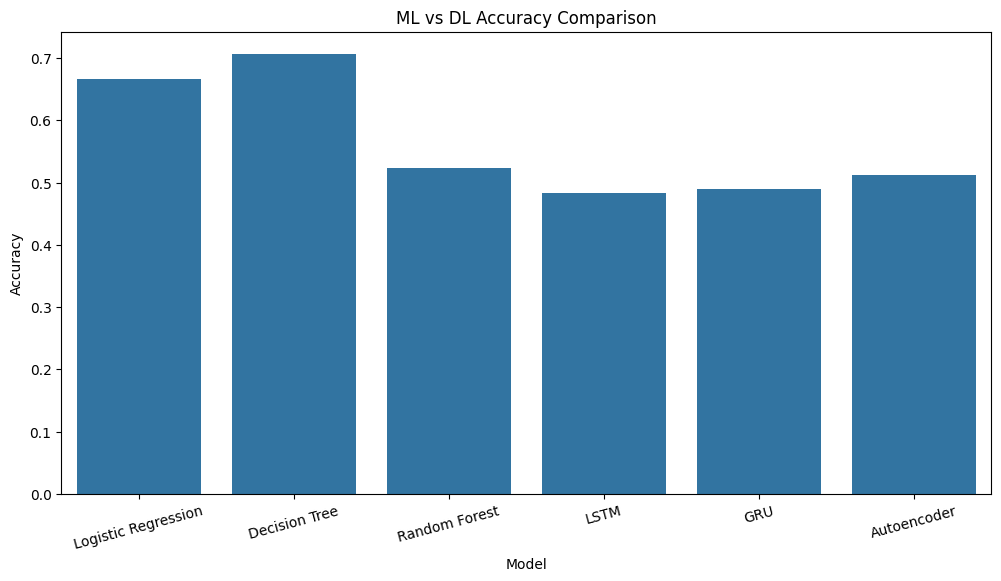

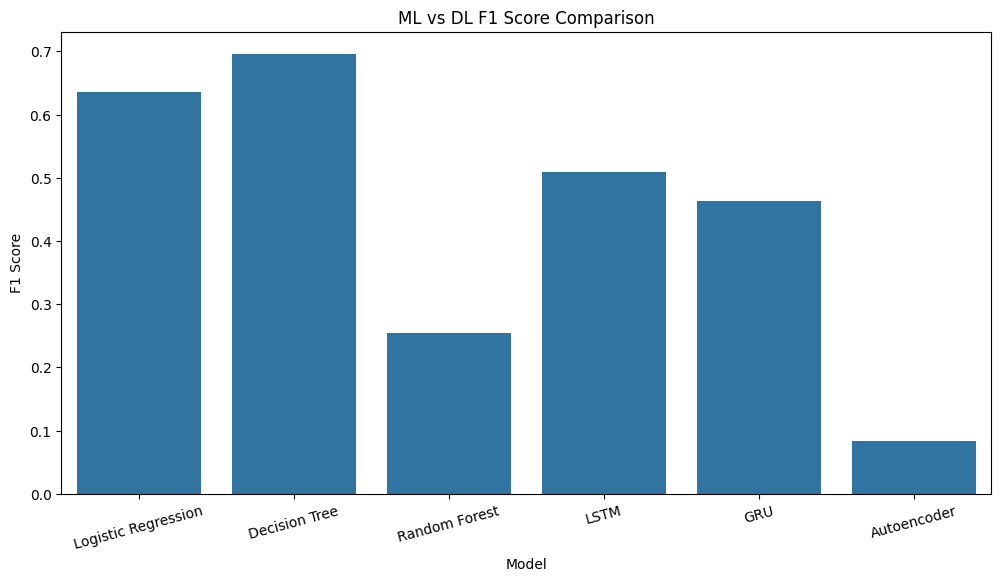


Feature Importance
               Feature  Importance
4           Error_Rate    0.189303
2        Disk_IO(MB/s)    0.166921
3  Network_Latency(ms)    0.151798
1      Memory_Usage(%)    0.139958
0         CPU_Usage(%)    0.083094
6  memory_rolling_mean    0.065642
8          memory_lag1    0.065611
7             cpu_lag1    0.065164
5     cpu_rolling_mean    0.064819
9        high_cpu_flag    0.007690


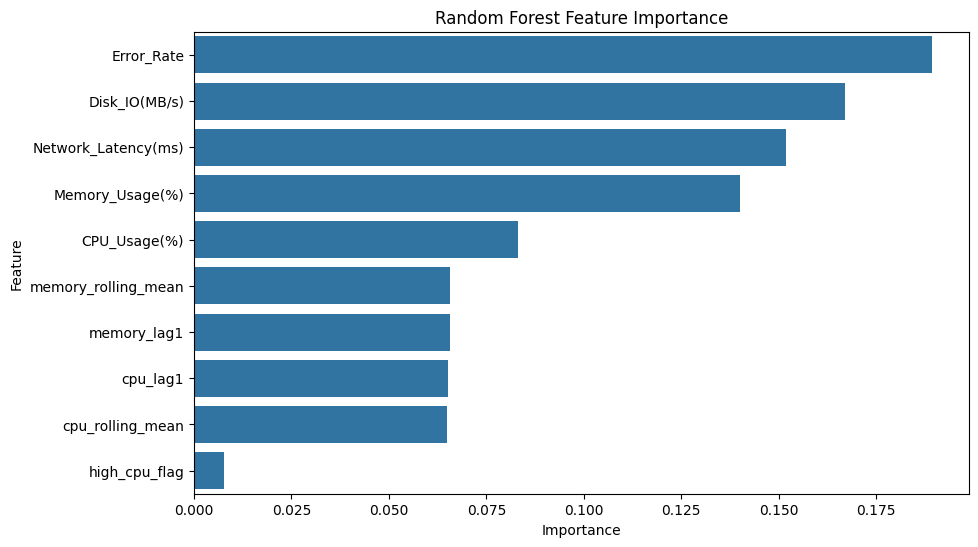

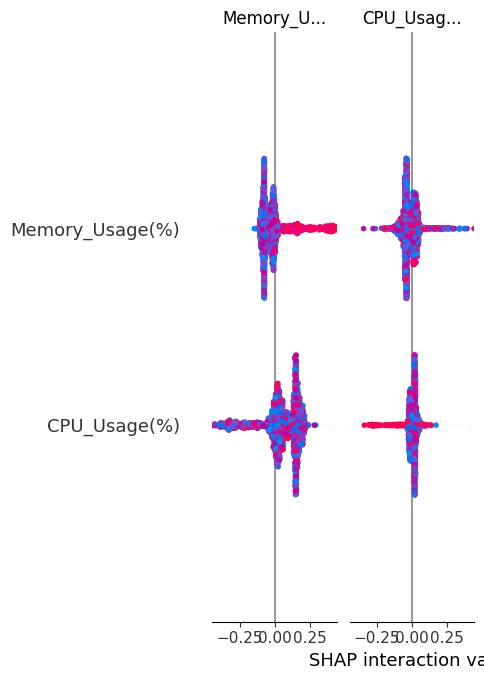

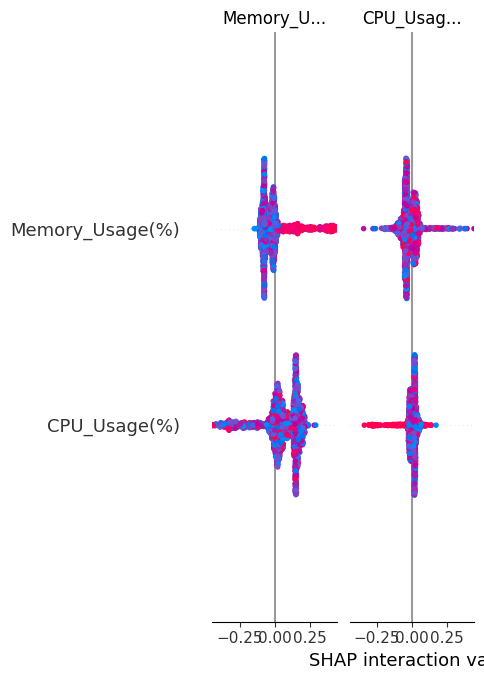


FINAL MODEL SELECTED: RANDOM FOREST

Reason:
- Best overall balanced performance
- Strong recall and F1-score
- Handles tabular data effectively
- More stable than deep learning models


Final comparison table saved successfully.
